# **UTS**

# **1.	Lakukan analisa klasifikasikan berita dengan extraksi fitur model topik modelling dengan classifier naïve bayes dan SVM**

## load data

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/Berita.csv")

# Gabungkan kolom judul dan berita
df["teks"] = df["judul"].astype(str) + " " + df["berita"]

# Cek data
df.head()


,No,judul,berita,tanggal,kategori,link,teks
0,1,Airlangga Harap Kenaikan UMP Tingkatkan Daya B...,Menteri Koordinator (Menko) Bidang Perekonomia...,"Minggu, 01 Des 2024 23:40 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412012...,Airlangga Harap Kenaikan UMP Tingkatkan Daya B...
1,2,PT SIER Beri Penghargaan untuk 50 Tenant Terba...,"Dalam rangka memeriahkan hari jadi ke-50, PT S...","Minggu, 01 Des 2024 20:45 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412012...,PT SIER Beri Penghargaan untuk 50 Tenant Terba...
2,3,Prabowo Bakal Bentuk Kementerian Penerimaan Ne...,Wacana Presiden Prabowo Subianto akan membentu...,"Minggu, 01 Des 2024 19:40 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...,Prabowo Bakal Bentuk Kementerian Penerimaan Ne...
3,4,Sinergi Kemenag & BPJS Ketenagakerjaan Lindung...,BPJS Ketenagakerjaan dan Kementerian Agama (Ke...,"Minggu, 01 Des 2024 19:03 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...,Sinergi Kemenag & BPJS Ketenagakerjaan Lindung...
4,5,Pemerintah Segera Bentuk Satgas PHK Usai Tetap...,Pemerintah akan segera membentuk Satuan Tugas ...,"Minggu, 01 Des 2024 19:00 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...,Pemerintah Segera Bentuk Satgas PHK Usai Tetap...


In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.4 MB/s eta 0:00:00


## PREPROCESSING

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory


In [ ]:
nltk.download("stopwords")

# Ambil stopwords bahasa Indonesia
stop_words = set(stopwords.words("indonesian"))
print(f"Jumlah stopwords: {len(stop_words)}")


Jumlah stopwords: 757


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Gunakan Sastrawi untuk stemming
factory = StemmerFactory()
stemmer = factory.create_stemmer()


In [ ]:
def clean_text(text):
    # Ubah ke huruf kecil
    text = text.lower()

    # Hapus karakter non-huruf (angka, tanda baca, simbol)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenisasi (pisah kata)
    tokens = text.split()

    # Hapus stopwords dan lakukan stemming
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]

    # Gabungkan kembali ke bentuk kalimat
    return " ".join(tokens)


In [ ]:
# Pastikan nama kolom teks sesuai dataset kamu (misal: "berita" atau "teks")
df["clean_text"] = df["teks"].apply(clean_text)

# Tampilkan hasil awal
df[["teks", "clean_text"]]

,teks,clean_text
0,Airlangga Harap Kenaikan UMP Tingkatkan Daya B...,airlangga harap naik ump tingkat daya beli mas...
1,PT SIER Beri Penghargaan untuk 50 Tenant Terba...,pt sier harga tenant baik hut rangka riah pt s...
2,Prabowo Bakal Bentuk Kementerian Penerimaan Ne...,prabowo bentuk menteri terima negara pimpin an...
3,Sinergi Kemenag & BPJS Ketenagakerjaan Lindung...,sinergi kemenag bpjs ketenagakerjaan lindung r...
4,Pemerintah Segera Bentuk Satgas PHK Usai Tetap...,perintah bentuk satgas phk tetap ump persen pe...
...,...,...
1495,Laporan Sebab Tabrakan Pesawat-Black Hawk Dita...,lapor tabrak pesawatblack hawk target selesai ...
1496,"Israel Bebaskan 110 Sandera Palestina, Diantar...",israel bebas sandera palestina antar ramal isr...
1497,Hamas Konfirmasi Kematian Komandan Al Qassam M...,hamas konfirmasi mati komandan al qassam moham...
1498,Black Box American Airlines Ditemukan Usai Tab...,black box american airlines temu tabrak black ...


## TOPIC MODELLING (LDA)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Konversi teks jadi bag of words
vectorizer = CountVectorizer(max_features=2000)
X_bow = vectorizer.fit_transform(df["clean_text"])

# Buat model LDA
lda = LatentDirichletAllocation(n_components=10, random_state=42)
X_topics = lda.fit_transform(X_bow)

print("Shape fitur LDA:", X_topics.shape)


Shape fitur LDA: (1500, 10)


## SPLIT DATA

In [ ]:
from sklearn.model_selection import train_test_split

X = X_topics
y = df["kategori"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## KLASIFIKASI NAIVE BAYES

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("=== Naive Bayes ===")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))


=== Naive Bayes ===
Accuracy: 0.89
               precision    recall  f1-score   support

      Ekonomi       0.88      0.88      0.88        73
Internasional       0.92      0.87      0.90        84
     Nasional       0.76      0.83      0.79        70
     Olahraga       1.00      0.99      0.99        73

     accuracy                           0.89       300
    macro avg       0.89      0.89      0.89       300
 weighted avg       0.89      0.89      0.89       300



## KLASIFIKASI SVM

In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("=== SVM ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


=== SVM ===
Accuracy: 0.8733333333333333
               precision    recall  f1-score   support

      Ekonomi       0.86      0.86      0.86        73
Internasional       0.89      0.87      0.88        84
     Nasional       0.74      0.79      0.76        70
     Olahraga       1.00      0.97      0.99        73

     accuracy                           0.87       300
    macro avg       0.87      0.87      0.87       300
 weighted avg       0.88      0.87      0.87       300



# **2.	Lakukan  analisa clustering dokumen pada data email**


## import libary

In [3]:
import pandas as pd
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


## load data

In [13]:
# Baca file spam.csv
df = pd.read_csv("spam.csv", encoding='latin-1')

# Tampilkan beberapa data teratas
df

,id,Text,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,1,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,2,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,3,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,4,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,5,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,5568,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,5569,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,5570,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,5571,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


## cek struktur data

In [15]:
print("Jumlah data:", len(df))
print("Kolom dataset:", df.columns.tolist())
print("\nData contoh:\n", df["Text"])


Jumlah data: 5572
Kolom dataset: ['id', 'Text', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Data contoh:
 0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                Will Ì_ b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: Text, Length: 5572, dtype: object


## Preprocessing

In [17]:
import re
import string

def clean_text(text):
    text = text.lower()  # ubah ke huruf kecil
    text = re.sub(r"http\S+", "", text)  # hapus URL
    text = re.sub(r"[^a-z\s]", "", text)  # hapus angka dan tanda baca
    return text

df["clean_text"] = df["Text"].apply(clean_text)
df


,id,Text,Unnamed: 2,Unnamed: 3,Unnamed: 4,clean_text
0,1,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,go until jurong point crazy available only in ...
1,2,Ok lar... Joking wif u oni...,NaN,NaN,NaN,ok lar joking wif u oni
2,3,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,free entry in a wkly comp to win fa cup final...
3,4,U dun say so early hor... U c already then say...,NaN,NaN,NaN,u dun say so early hor u c already then say
4,5,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,nah i dont think he goes to usf he lives aroun...
...,...,...,...,...,...,...
5567,5568,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN,this is the nd time we have tried contact u u...
5568,5569,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN,will b going to esplanade fr home
5569,5570,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN,pity was in mood for that soany other suggest...
5570,5571,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN,the guy did some bitching but i acted like id ...


## TF-IDF

In [18]:
vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
X = vectorizer.fit_transform(df["clean_text"])

print("Shape TF-IDF:", X.shape)


Shape TF-IDF: (5572, 1000)


## Membagi jumlah cluster = 2 (spam & non spam)

In [19]:
num_clusters = 2
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(X)

# Simpan hasil cluster
df["cluster"] = kmeans.labels_


## Hasil Cluster

In [10]:
for i in range(num_clusters):
    print(f"\nCluster {i}:")
    sample = df[df["cluster"] == i]["Text"].head(5)
    print(sample.values)



Cluster 0:
['Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'
 'Ok lar... Joking wif u oni...'
 "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"
 'U dun say so early hor... U c already then say...'
 "Nah I don't think he goes to usf, he lives around here though"]

Cluster 1:
["I'm back &amp; we're packing the car now, I'll let you know if there's room"
 "Oops, I'll let you know when my roommate's done"
 'Wow. I never realized that you were so embarassed by your accomodations. I thought you liked it, since i was doing the best i could and you always seemed so happy about \\the cave\\". I\'m sorry I didn\'t and don\'t have more to give. I\'m sorry i offered. I\'m sorry your room was so embarassing."'
 "Sorry, I'll call later in meeting." "Sorry, I'll call later"]


## Visualisasi Cluster

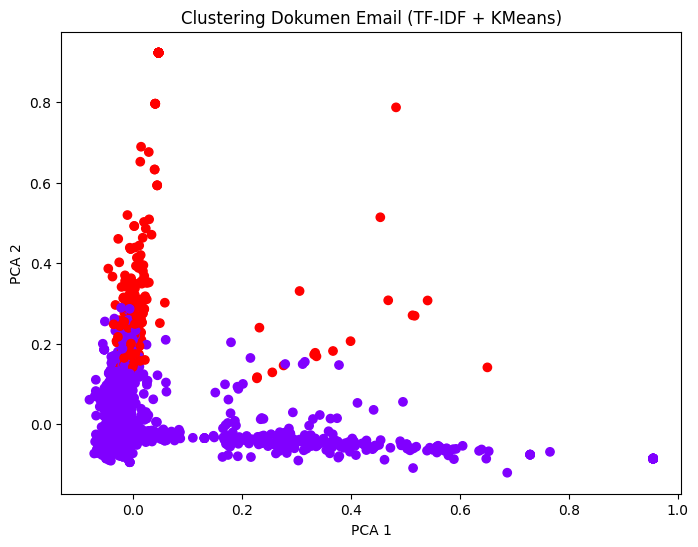

In [20]:
pca = PCA(n_components=2)
reduced_X = pca.fit_transform(X.toarray())

plt.figure(figsize=(8,6))
plt.scatter(reduced_X[:, 0], reduced_X[:, 1], c=df["cluster"], cmap="rainbow")
plt.title("Clustering Dokumen Email (TF-IDF + KMeans)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


In [21]:
from sklearn.metrics import silhouette_score

# Hitung skor siluet (semakin tinggi semakin baik, rentang -1 s/d 1)
score = silhouette_score(X, df["cluster"])
print(f"Silhouette Score: {score:.3f}")


Silhouette Score: 0.014
